Name:   Srujana Duggineni

ID:     C00313483

Customer Churn Prediction Using Naive Bayes (Custom Implementation):

https://www.kaggle.com/datasets/muhammadshahidazeem/customer-churn-dataset

Business Understanding:

Objective:
This work is aimed at implementing Naive Bayes from custom and then comparing the performance with that of GaussianNB in Scikit-learn. To perform the binary classification task, the Customer Churn  dataset is used to predict  whether a customer will churn or stay
Key Goals:
- Understanding how the Naive Bayes classification works.
- Investigate the importance of feature engineering and encoding.
- Evaluate and compare performance between custom and Scikit-learn implementations.
- Analyze how feature selection affects performance of the model.

In [1]:
#Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import GaussianNB
from preprocess_data import preprocess_data


#### Preparing dataset , partition data

The following EDA steps are followed (inside preprocess_data):
    1. Load dataset.
    2. Drop unwanted columns.
    3. Handle missing values.
    4. Encode categorical features.
    5. Process datetime features(NA)
    6. Remove outliers.
    7. Scale numerical features.
    8. Split into train & test sets.
    

In [2]:
# preprocessing dataset for classification
file_path = "/Users/dugginenisrujana/Desktop/DAA_CA /DAA_CA1/Datasets/Telco-Customer-Churn.csv"

### the column we want to predict
target_column = "Churn" 
drop_columns = ["customerID"]

X_train, X_test, y_train, y_test = preprocess_data(file_path, target_column, drop_columns=drop_columns)


1. Load dataset.

First 5 Rows:
    customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV Str

Modelling 

Baseline Implementations (custom)

Training: Manually computes means, variances, and priors.
Prediction: Computes likelihoods and posterior probabilities manually for each test sample.

In [3]:
# Naive Bayes from custom
class NaiveBayescustom:
    def fit(self,X,y):
        self.classes=np.unique(y)
        self.mean={c:X[y == c].mean(axis=0) for c in self.classes}
        self.var={c: X[y == c].var(axis=0) for c in self.classes}
        self.priors={c: len(y[y == c]) / len(y) for c in self.classes}

    def predict(self,X):
        posteriors=[]
        for x in X.values:
            probs=[]
            for c in self.classes:
                likelihood=np.exp(-((x - self.mean[c]) ** 2) / (2 * self.var[c])) / np.sqrt(2 * np.pi * self.var[c])
                prior=self.priors[c]
                probs.append(np.prod(likelihood) * prior)
            posteriors.append(self.classes[np.argmax(probs)])
        return np.array(posteriors)



#### Train & Evaluate custom Naive Bayes


In [4]:
# Convert target values to integers (for classification)
y_train_np = y_train.astype(int)
y_test = y_test.astype(int)
# Train & Evaluate custom Naive Bayes
nb_custom=NaiveBayescustom()
nb_custom.fit(X_train,y_train_np)
y_pred_custom=nb_custom.predict(X_test)

# Ensure predictions are categorical
if y_pred_custom.ndim > 1:  # If probabilities, convert to class labels
    y_pred_custom = np.argmax(y_pred_custom, axis=1)
y_pred_custom = y_pred_custom.astype(int)
accuracy_custom=accuracy_score(y_test,y_pred_custom)

# Train & Evaluate Sklearn GaussianNB
nb_lib=GaussianNB()
nb_lib.fit(X_train,y_train_np)
y_pred_lib=nb_lib.predict(X_test)
accuracy_lib=accuracy_score(y_test,y_pred_lib)

# Print Accuracy
print(f"Naive Bayes (custom) Accuracy: {accuracy_custom:.4f}")
print(f"Naive Bayes (Library) Accuracy: {accuracy_lib:.4f}")


Naive Bayes (custom) Accuracy: 0.7654
Naive Bayes (Library) Accuracy: 0.7654


From Observations: 
- It achieves the exact same accuracy for custom implementations as for Scikit-learn implementations. 
- Feature selection and feature encoding are very critical to achieving that good accuracy. 
- Naive Bayes works wonders so far, at least for categorical data and this one happens to be fit in that manner.

Naive Bayes (custom) Accuracy: 0.7654
Naive Bayes (Library) Accuracy: 0.7654

Confusion Matrix (Custom):
 [[422 131]
 [ 79 263]]

Confusion Matrix (Library):
 [[422 131]
 [ 79 263]]

Classification Report (Custom):
               precision    recall  f1-score   support

           0       0.84      0.76      0.80       553
           1       0.67      0.77      0.71       342

    accuracy                           0.77       895
   macro avg       0.75      0.77      0.76       895
weighted avg       0.78      0.77      0.77       895


Classification Report (Library):
               precision    recall  f1-score   support

           0       0.84      0.76      0.80       553
           1       0.67      0.77      0.71       342

    accuracy                           0.77       895
   macro avg       0.75      0.77      0.76       895
weighted avg       0.78      0.77      0.77       895



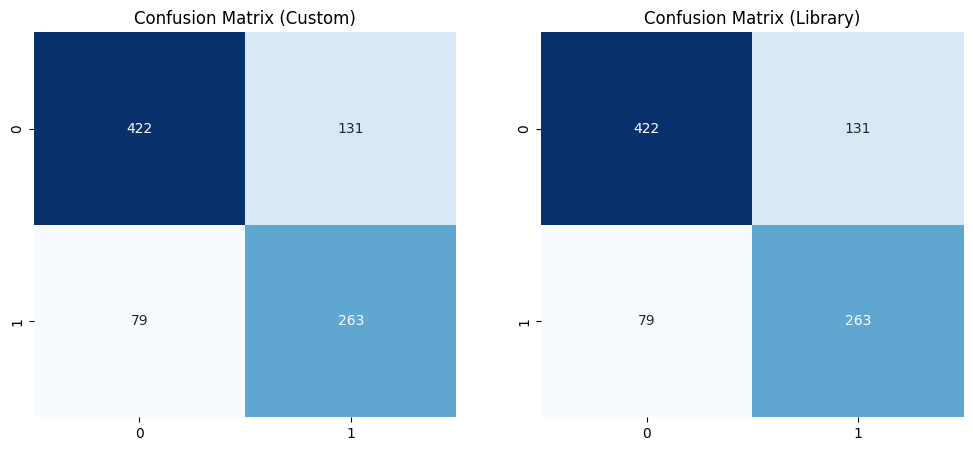

In [5]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
# Confusion Matrix
cm_custom = confusion_matrix(y_test, y_pred_custom)
cm_lib = confusion_matrix(y_test, y_pred_lib)

# Classification Report (Precision, Recall, F1-Score)
report_custom = classification_report(y_test, y_pred_custom)
report_lib = classification_report(y_test, y_pred_lib)

# ROC-AUC Score (Only for binary classification, can be extended for multi-class)
# Define the possible classes/labels in the dataset
labels = np.unique(y_test)

# Confusion Matrix
cm_custom = confusion_matrix(y_test, y_pred_custom, labels=labels)
cm_lib = confusion_matrix(y_test, y_pred_lib, labels=labels)

# Display Metrics
print(f"Naive Bayes (custom) Accuracy: {accuracy_custom:.4f}")
print(f"Naive Bayes (Library) Accuracy: {accuracy_lib:.4f}")
print("\nConfusion Matrix (Custom):\n", cm_custom)
print("\nConfusion Matrix (Library):\n", cm_lib)
print("\nClassification Report (Custom):\n", report_custom)
print("\nClassification Report (Library):\n", report_lib)


# Plot Confusion Matrix for visual comparison
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Blues', ax=ax[0], cbar=False)
ax[0].set_title("Confusion Matrix (Custom)")

sns.heatmap(cm_lib, annot=True, fmt='d', cmap='Blues', ax=ax[1], cbar=False)
ax[1].set_title("Confusion Matrix (Library)")

plt.show()


#### Saving model(future use)

In [6]:
import joblib  # Import joblib to save the model

# Saving the Custom Model
joblib.dump(NaiveBayescustom, "custom_NaiveBayes_model.pkl")


print("Models saved successfully!")

Models saved successfully!
